# ModernBERT baseline — Authorship Attribution

This notebook replicates the three BERT baselines from `baseline.ipynb` using **`answerdotai/ModernBERT-base`** as the backbone.

Key differences from the BERT baseline:
- **Model**: `answerdotai/ModernBERT-base` (149M params, released Dec 2024)
- Texts are tokenized with `truncation=True` — the model's own maximum is the only limit.
- **No `token_type_ids`**: ModernBERT does not use segment embeddings; the tokenizer will not produce them.
- All other settings (datasets, seeds, WeightedTrainer, metrics) are identical to `baseline.ipynb` for direct comparison.

## Tasks
1. **PAN25 Binary** — human vs. AI text (2-class)
2. **PAN25 Multi-class** — 23-class LLM-source attribution
3. **AuthorMix Multi-class** — 14-class author/style attribution

In [ ]:
import glob, shutil
for p in glob.glob("/usr/local/lib/python*/dist-packages/~*"):
    shutil.rmtree(p, ignore_errors=True)
    print(f"Removed corrupted partial install: {p}")

# Colab (2025+) ships numpy>=2, scipy>=1.13, scikit-learn>=1.6 as defaults.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                "transformers>=4.48.0",
                "datasets", "accelerate", "captum", "matplotlib", "scikit-learn"],
               check=True)

import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
# reduce GPU memory fragmentation, avoid OOM on long sequences
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

Mounted at /content/drive


In [ ]:
import os, json, gc, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.preprocessing import LabelEncoder
from collections import Counter

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

ROOT      = "/content/drive/MyDrive/ap-thesis"
RUNS_ROOT = f"{ROOT}/runs"
os.makedirs(f"{RUNS_ROOT}/results", exist_ok=True)
os.makedirs(f"{RUNS_ROOT}/models",  exist_ok=True)

BASE_MODEL = "answerdotai/ModernBERT-base"
SEEDS = [11, 18, 2022]  # same seeds as BERT baseline for direct comparison

def free_gpu():
    """Release GPU memory between seed runs."""
    gc.collect()
    torch.cuda.empty_cache()

DEVICE: cuda
GPU: Tesla T4


## Tokenizer

`truncation=True` without `max_length` - HuggingFace tokenizer uses the model's own maximum (8192 for ModernBERT). This is the only truncation applied.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
print("Tokenizer max length (model native):", tokenizer.model_max_length)

def tokenize_fn(batch):
    # No max_length — ModernBERT handles up to 8192 tokens natively.
    return tokenizer(batch["text"], truncation=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy":          accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1_macro":          f1_score(labels, preds, average="macro"),
        "f1_weighted":       f1_score(labels, preds, average="weighted"),
    }

def make_args(output_dir, seed, lr=2e-5, epochs=3,
              train_bs=1, eval_bs=4, grad_acc=16,
              gradient_checkpointing=True, metric="f1_macro"):
    """
    Memory-efficient defaults for T4 (15 GB) with full-length ModernBERT.

    PAN25 texts average 864 tokens (p95=1256, max=3397).
    train_bs=1, grad_acc=16 → effective batch=16 (same as BERT baseline).
    gradient_checkpointing  → recomputes activations on backward; ~30% slower
                              but cuts activation memory ~60-70%.

    remove_unused_columns=False: the dataset stores labels as 'label' (singular)
    but the model's forward() signature uses 'labels' (plural). HF Trainer's
    default remove_unused_columns=True silently drops 'label' before compute_loss
    runs, making labels=None. Setting False keeps it in the batch so
    WeightedTrainer.compute_loss can pop it before calling model().
    """
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        gradient_accumulation_steps=grad_acc,
        num_train_epochs=epochs,
        logging_steps=50,
        report_to="none",
        seed=seed,
        fp16=(DEVICE == "cuda"),
        gradient_checkpointing=gradient_checkpointing,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model=metric,
        remove_unused_columns=False,
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer max length (model native): 8192


## 1. PAN25 - Binary classification (Human vs. AI)

**Data**: `pan25/train.jsonl` → stratified 70/15/15 split  
**Target**: `label ∈ {0, 1}`  
**Model**: `answerdotai/ModernBERT-base`, `num_labels=2`  
**Seeds**: `[11, 18, 2022]`

In [ ]:
pan_path_drive = f"{ROOT}/data/pan25/train.jsonl"
assert os.path.exists(pan_path_drive), f"Not found: {pan_path_drive}"

pan_path = "/content/train.jsonl"
!cp "{pan_path_drive}" "{pan_path}"

with open(pan_path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f]

df_pan = pd.DataFrame(rows)
assert {"text", "label"}.issubset(df_pan.columns)
assert set(df_pan["label"].unique()) <= {0, 1}

df_train, df_tmp = train_test_split(
    df_pan, test_size=0.30, random_state=42, stratify=df_pan["label"]
)
df_val, df_test = train_test_split(
    df_tmp, test_size=0.50, random_state=42, stratify=df_tmp["label"]
)

def to_ds(df):
    return Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True), preserve_index=False)

pan_ds = DatasetDict(train=to_ds(df_train), validation=to_ds(df_val), test=to_ds(df_test))
print("Train/Val/Test:", len(pan_ds["train"]), len(pan_ds["validation"]), len(pan_ds["test"]))

Train/Val/Test: 16594 3556 3557


In [ ]:
start = time.time()
pan_ds_tok = pan_ds.map(
    tokenize_fn, batched=True, remove_columns=["text"],
    num_proc=1, desc="Tokenizing PAN25 binary (ModernBERT, no max_length)"
)
print(f"Tokenization: {time.time() - start:.1f}s")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Report actual token lengths — no truncation expected for most texts
sample_lens = [len(pan_ds_tok["train"][i]["input_ids"]) for i in range(min(500, len(pan_ds_tok["train"])))]
print(f"Train token length — mean: {np.mean(sample_lens):.0f}, max: {np.max(sample_lens)}, p95: {np.percentile(sample_lens, 95):.0f}")
print("Columns:", pan_ds_tok["train"].column_names)

Tokenizing PAN25 binary (ModernBERT, no max_length) (num_proc=1):   0%|          | 0/16594 [00:00<?, ? example…

Tokenizing PAN25 binary (ModernBERT, no max_length) (num_proc=1):   0%|          | 0/3556 [00:00<?, ? examples…

Tokenizing PAN25 binary (ModernBERT, no max_length) (num_proc=1):   0%|          | 0/3557 [00:00<?, ? examples…

Tokenization: 75.1s
Train token length — mean: 864, max: 3397, p95: 1256
Columns: ['label', 'input_ids', 'attention_mask']


In [ ]:
def run_pan25_binary_one_seed(seed):
    free_gpu()
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)
    model.to(DEVICE)

    # train_bs=1, grad_acc=16 → effective batch=16; gradient_checkpointing saves ~60% activation memory
    args = make_args(
        output_dir=f"{RUNS_ROOT}/modernbert_pan25_binary_seed{seed}",
        seed=seed,
        train_bs=1, eval_bs=4, grad_acc=16,
        gradient_checkpointing=True,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=pan_ds_tok["train"],
        eval_dataset=pan_ds_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(pan_ds_tok["test"]).items()}
    return test_metrics, trainer

pan_rows = []
best_bin = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// PAN25 binary (ModernBERT) — seed {s}")
    m, tr = run_pan25_binary_one_seed(s)
    pan_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_bin["f1"]:
        best_bin = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

pan_bin_df = pd.DataFrame(pan_rows).sort_values("eval_f1_macro", ascending=False)
display(pan_bin_df)

pan_bin_df.to_csv(f"{RUNS_ROOT}/results/pan25_binary_modernbert_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/pan25_binary_modernbert_seeds.csv")


/// PAN25 binary (ModernBERT) — seed 11


[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,0.397700,0.059979,0.992126,0.992644,0.991693,0.992133
2,0.353106,0.035401,0.994376,0.994469,0.994060,0.994378
3,0.133393,0.039940,0.993532,0.993923,0.993173,0.993537


Training Loss,Validation Loss,Epoch,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
0.133393,0.031821,3,0.995783,0.996301,0.995550,0.995786



/// PAN25 binary (ModernBERT) — seed 18


...

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,1.368642,0.029937,0.994938,0.994926,0.994652,0.994940
2,0.186106,0.036106,0.994657,0.995526,0.994365,0.994663
3,0.000197,0.024770,0.996907,0.996937,0.996732,0.996907


Training Loss,Validation Loss,Epoch,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
0.000197,0.017286,3,0.997470,0.997670,0.997328,0.997471


,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted
1,18,0.015516,0.997470,0.997670,0.997328,0.997471
2,2022,0.017286,0.997470,0.997670,0.997328,0.997471
0,11,0.031821,0.995783,0.996301,0.995550,0.995786


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_binary_modernbert_seeds.csv


In [ ]:
best_bin_dir = f"{RUNS_ROOT}/models/pan25_binary_modernbert_best_seed{best_bin['seed']}"
os.makedirs(best_bin_dir, exist_ok=True)
best_bin["trainer"].save_model(best_bin_dir)
tokenizer.save_pretrained(best_bin_dir)
print("Saved best binary model to:", best_bin_dir)
print("Best seed:", best_bin["seed"], "| Best macro-F1:", round(best_bin["f1"], 4))

Saved best binary model to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_binary_modernbert_best_seed18
Best seed: 18 | Best macro-F1: 0.9973


## 2. PAN25 - Multi-class **classification** (23 LLM sources)

**Target**: `model` column (23 classes)  
**Trainer**: `WeightedTrainer` with class-weighted CE  
**Seeds**: `[11, 18, 2022]`  
**Key difference from BERT**: full texts are passed without truncation, giving the model access to stylistic cues beyond the first 512 tokens.

In [ ]:
assert "model" in df_train.columns, "Expected 'model' column in PAN25 data."

df_train_mc = df_train.copy()
df_val_mc   = df_val.copy()
df_test_mc  = df_test.copy()

le_mc = LabelEncoder()
le_mc.fit(pd.concat([df_train_mc["model"], df_val_mc["model"], df_test_mc["model"]]))

df_train_mc["label_mc"] = le_mc.transform(df_train_mc["model"])
df_val_mc["label_mc"]   = le_mc.transform(df_val_mc["model"])
df_test_mc["label_mc"]  = le_mc.transform(df_test_mc["model"])

num_labels_mc = len(le_mc.classes_)
print("num_labels_mc:", num_labels_mc)

def to_ds_mc(df):
    return Dataset.from_pandas(
        df[["text", "label_mc"]].rename(columns={"label_mc": "label"}).reset_index(drop=True),
        preserve_index=False
    )

pan_mc = DatasetDict(
    train=to_ds_mc(df_train_mc),
    validation=to_ds_mc(df_val_mc),
    test=to_ds_mc(df_test_mc),
)

start = time.time()
pan_mc_tok = pan_mc.map(
    tokenize_fn, batched=True, remove_columns=["text"],
    num_proc=1, load_from_cache_file=False,
    desc="Tokenizing PAN25 multiclass (ModernBERT, no max_length)"
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(f"Tokenization: {time.time() - start:.1f}s")
print("Columns:", pan_mc_tok["train"].column_names)

sample_lens = [len(pan_mc_tok["train"][i]["input_ids"]) for i in range(min(200, len(pan_mc_tok["train"])))]
print(f"Token length — mean: {np.mean(sample_lens):.0f}, max: {np.max(sample_lens)}, p95: {np.percentile(sample_lens, 95):.0f}")

num_labels_mc: 23


Tokenizing PAN25 multiclass (ModernBERT, no max_length):   0%|          | 0/16594 [00:00<?, ? examples/s]

Tokenizing PAN25 multiclass (ModernBERT, no max_length):   0%|          | 0/3556 [00:00<?, ? examples/s]

Tokenizing PAN25 multiclass (ModernBERT, no max_length):   0%|          | 0/3557 [00:00<?, ? examples/s]

Tokenization: 77.0s
Columns: ['label', 'input_ids', 'attention_mask']
Token length — mean: 866, max: 3397, p95: 1251


In [ ]:
cnt = Counter(df_train_mc["label_mc"].tolist())
weights_mc = torch.tensor(
    [len(df_train_mc) / cnt[c] for c in range(num_labels_mc)], dtype=torch.float
).to(DEVICE)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Pop labels from inputs before passing to model.
        # With remove_unused_columns=False, 'label' (singular) stays in the batch.
        # We must pop it — not just read it — so it is not forwarded to model().
        labels = inputs.pop("labels", None)
        if labels is None:
            labels = inputs.pop("label", None)
        outputs = model(**inputs)
        loss = F.cross_entropy(outputs.logits, labels, weight=weights_mc)
        return (loss, outputs) if return_outputs else loss

def run_pan25_mc_one_seed(seed):
    free_gpu()
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=num_labels_mc)
    model.to(DEVICE)

    args = make_args(
        output_dir=f"{RUNS_ROOT}/modernbert_pan25_multiclass_seed{seed}",
        seed=seed,
        train_bs=1, eval_bs=4, grad_acc=16,
        gradient_checkpointing=True,
    )
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=pan_mc_tok["train"],
        eval_dataset=pan_mc_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(pan_mc_tok["test"]).items()}
    return test_metrics, trainer

In [ ]:
mc_rows = []
best_mc = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// PAN25 MULTICLASS (ModernBERT) — seed {s}")
    m, tr = run_pan25_mc_one_seed(s)
    mc_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_mc["f1"]:
        best_mc = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

mc_df = pd.DataFrame(mc_rows).sort_values("eval_f1_macro", ascending=False)
display(mc_df)
mc_df.to_csv(f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_seeds.csv")


/// PAN25 MULTICLASS (ModernBERT) — seed 11


ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
W0501 20:10:20.352000 12607 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,9.877806,0.905625,0.804274,0.647279,0.641895,0.792467
2,5.136646,0.632931,0.867548,0.725383,0.730439,0.864711
3,1.579443,0.548772,0.890607,0.780522,0.782438,0.889578



/// PAN25 MULTICLASS (ModernBERT) — seed 18


ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


/// PAN25 MULTICLASS (ModernBERT) — seed 2022


ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,9.182345,0.837113,0.820866,0.642349,0.647512,0.814289
2,3.666183,0.643193,0.868673,0.729014,0.731739,0.863301
3,1.373529,0.534846,0.892295,0.788969,0.789139,0.892561


,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
2,2022,0.511886,0.898791,0.802388,0.803713,0.898129,163.6330,21.738,5.439,3.0
1,18,0.515247,0.893168,0.798030,0.799272,0.892395,163.2802,21.785,5.451,3.0
0,11,0.529784,0.894855,0.789605,0.790802,0.893082,168.0513,21.166,5.296,3.0


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_modernbert_seeds.csv


In [ ]:
best_mc_dir = f"{RUNS_ROOT}/models/pan25_multiclass_modernbert_best_seed{best_mc['seed']}"
os.makedirs(best_mc_dir, exist_ok=True)
best_mc["trainer"].save_model(best_mc_dir)
tokenizer.save_pretrained(best_mc_dir)

# Save tokenized dataset
tok_dir_pmc = f"{RUNS_ROOT}/cache/pan25_multiclass_tok_modernbert"
pan_mc_tok.save_to_disk(tok_dir_pmc)

# Save label map
label_map_pmc = {int(i): cls for i, cls in enumerate(le_mc.classes_)}
with open(f"{RUNS_ROOT}/models/pan25_multiclass_modernbert_label_map.json", "w") as f:
    json.dump(label_map_pmc, f, indent=2)

print("Saved best multiclass model to:", best_mc_dir)
print("Best seed:", best_mc["seed"], "| Best macro-F1:", round(best_mc["f1"], 4))
print("Tokenized dataset:", tok_dir_pmc)

Saving the dataset (0/1 shards):   0%|          | 0/16594 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3556 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3557 [00:00<?, ? examples/s]

Saved best multiclass model to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_multiclass_modernbert_best_seed2022
Best seed: 2022 | Best macro-F1: 0.8037
Tokenized dataset: /content/drive/MyDrive/ap-thesis/runs/cache/pan25_multiclass_tok_modernbert


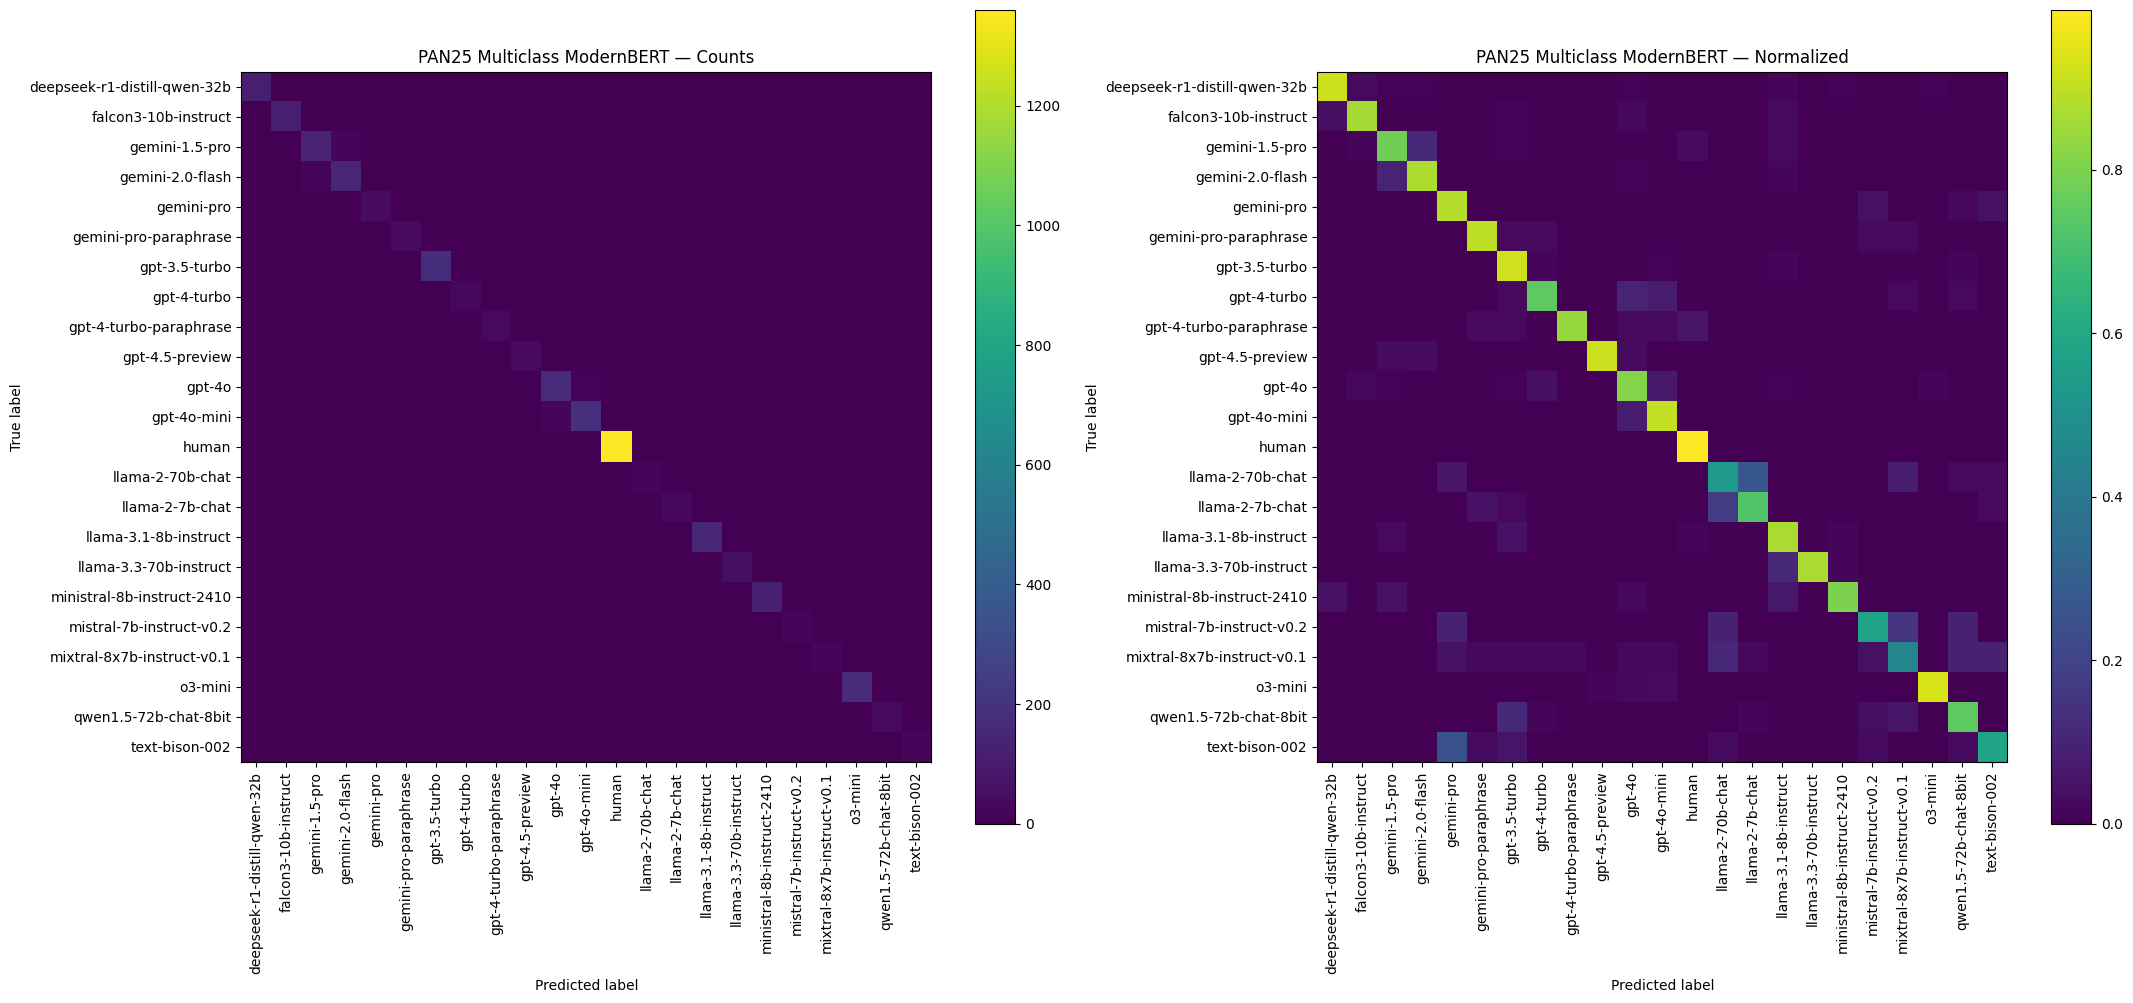

In [ ]:
pred = best_mc["trainer"].predict(pan_mc_tok["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=-1)
names  = list(le_mc.classes_)
labels = np.arange(len(names))

cm      = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, mat, title in zip(
    axes,
    [cm, cm_norm],
    ["PAN25 Multiclass ModernBERT — Counts", "PAN25 Multiclass ModernBERT — Normalized"],
):
    ConfusionMatrixDisplay(mat, display_labels=names).plot(
        include_values=False, xticks_rotation=90, ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_confusion_seed{best_mc['seed']}.png", dpi=200)
plt.show()

,class,precision,recall,f1,support
19,mixtral-8x7b-instruct-v0.1,0.571429,0.454545,0.506329,44.0
13,llama-2-70b-chat,0.555556,0.540541,0.547945,37.0
18,mistral-7b-instruct-v0.2,0.678571,0.575758,0.622951,33.0
22,text-bison-002,0.724138,0.583333,0.646154,36.0
7,gpt-4-turbo,0.681818,0.750000,0.714286,40.0
14,llama-2-7b-chat,0.707317,0.725000,0.716049,40.0
21,qwen1.5-72b-chat-8bit,0.735849,0.750000,0.742857,52.0
4,gemini-pro,0.709091,0.886364,0.787879,44.0
2,gemini-1.5-pro,0.798780,0.779762,0.789157,168.0
10,gpt-4o,0.811881,0.811881,0.811881,202.0


Saved per-class report to: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_modernbert_per_class_report_seed2022.csv


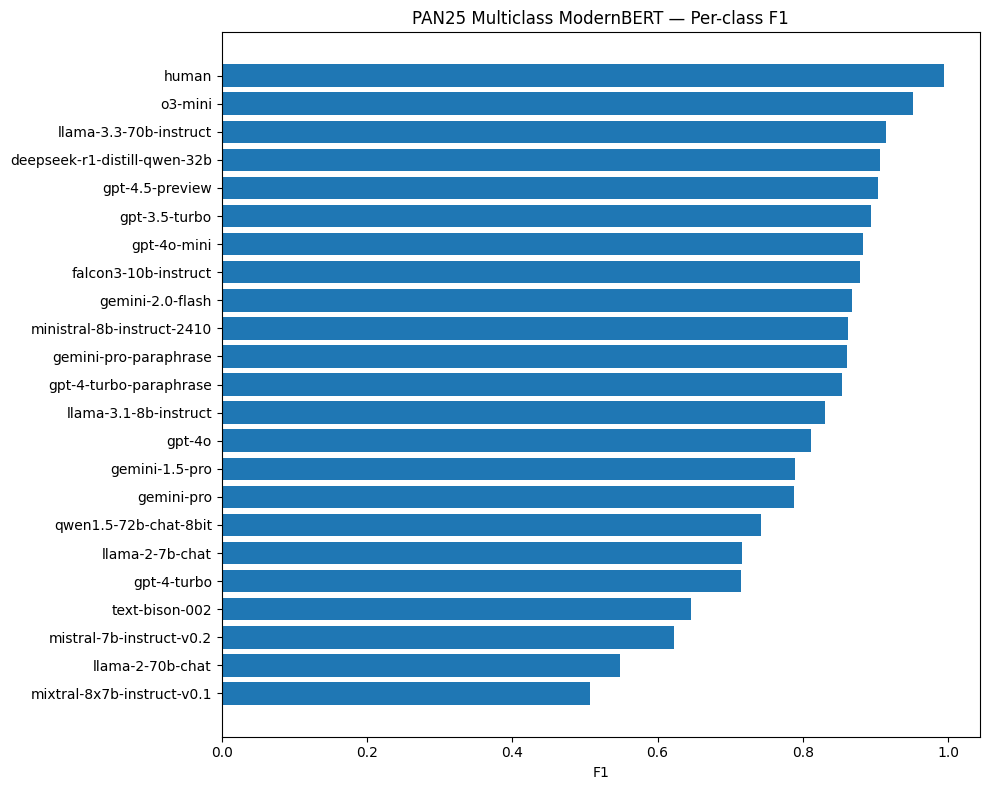

In [ ]:
report = classification_report(y_true, y_pred, target_names=names, output_dict=True, zero_division=0)
df_rep = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class", "f1-score": "f1"})
df_classes = df_rep[df_rep["class"].isin(names)].sort_values("f1", ascending=True)
display(df_classes[["class", "precision", "recall", "f1", "support"]])

out_csv = f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_per_class_report_seed{best_mc['seed']}.csv"
df_classes.to_csv(out_csv, index=False)
print("Saved per-class report to:", out_csv)

plt.figure(figsize=(10, 8))
plt.barh(df_classes["class"], df_classes["f1"])
plt.title("PAN25 Multiclass ModernBERT — Per-class F1")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_per_class_f1.png", dpi=200)
plt.show()

## 3. AuthorMix — Multi-class style attribution (14 classes)

**Files**: `AuthorMix-train.json`, `AuthorMix-val.json`, `AuthorMix-test.json`  
**Target**: `style` (LabelEncoder → `label`)  
**Trainer**: `WeightedTrainer` (class-weighted CE, new weights for this dataset)  
**Seeds**: `[11, 18, 2022]`  

AuthorMix texts tend to be shorter (speeches, blog posts) than PAN25, so the absence of a length cap has less impact here. Nevertheless, no limit is applied for consistency.

In [ ]:
AUTHORMIX_DIR    = f"{ROOT}/data/style-remix/AuthorMix"
LOCAL_AUTHORMIX  = "/content/AuthorMix"
!rm -rf "{LOCAL_AUTHORMIX}"
!cp -r "{AUTHORMIX_DIR}" "{LOCAL_AUTHORMIX}"

df_tr = pd.read_json(f"{LOCAL_AUTHORMIX}/AuthorMix-train.json")
df_va = pd.read_json(f"{LOCAL_AUTHORMIX}/AuthorMix-val.json")
df_te = pd.read_json(f"{LOCAL_AUTHORMIX}/AuthorMix-test.json")

print("Train/Val/Test:", df_tr.shape, df_va.shape, df_te.shape)
print("Columns:", df_tr.columns.tolist())

le_am = LabelEncoder()
le_am.fit(pd.concat([df_tr["style"], df_va["style"], df_te["style"]], ignore_index=True))

df_tr["label"] = le_am.transform(df_tr["style"])
df_va["label"] = le_am.transform(df_va["style"])
df_te["label"] = le_am.transform(df_te["style"])

num_labels_am = len(le_am.classes_)
print("AuthorMix num_labels:", num_labels_am)

def to_ds_am(df):
    return Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True), preserve_index=False)

amix = DatasetDict(train=to_ds_am(df_tr), validation=to_ds_am(df_va), test=to_ds_am(df_te))

Train/Val/Test: (14579, 3) (3642, 3) (4747, 3)
Columns: ['style', 'text', 'category']
AuthorMix num_labels: 14


In [ ]:
start = time.time()
amix_tok = amix.map(
    tokenize_fn, batched=True, remove_columns=["text"],
    num_proc=1, load_from_cache_file=False,
    desc="Tokenizing AuthorMix (ModernBERT, no max_length)"
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(f"Tokenization: {time.time() - start:.1f}s")

sample_lens = [len(amix_tok["train"][i]["input_ids"]) for i in range(min(200, len(amix_tok["train"])))]
print(f"Token length — mean: {np.mean(sample_lens):.0f}, max: {np.max(sample_lens)}, p95: {np.percentile(sample_lens, 95):.0f}")
print("Columns:", amix_tok["train"].column_names)

Tokenizing AuthorMix (ModernBERT, no max_length):   0%|          | 0/14579 [00:00<?, ? examples/s]

Tokenizing AuthorMix (ModernBERT, no max_length):   0%|          | 0/3642 [00:00<?, ? examples/s]

Tokenizing AuthorMix (ModernBERT, no max_length):   0%|          | 0/4747 [00:00<?, ? examples/s]

Tokenization: 5.7s
Token length — mean: 80, max: 163, p95: 138
Columns: ['label', 'input_ids', 'attention_mask']


In [ ]:
cnt_am = Counter(df_tr["label"].tolist())
weights_am = torch.tensor(
    [len(df_tr) / cnt_am[c] for c in range(num_labels_am)], dtype=torch.float
).to(DEVICE)

class WeightedTrainerAM(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Same pop pattern as WeightedTrainer — keeps 'label' out of model()
        labels = inputs.pop("labels", None)
        if labels is None:
            labels = inputs.pop("label", None)
        outputs = model(**inputs)
        loss = F.cross_entropy(outputs.logits, labels.long(), weight=weights_am)
        return (loss, outputs) if return_outputs else loss

def run_authormix_one_seed(seed):
    free_gpu()
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=num_labels_am)
    model.to(DEVICE)

    # AuthorMix texts are shorter → bs=2 is safe; grad_acc=8 keeps effective batch=16
    args = make_args(
        output_dir=f"{RUNS_ROOT}/modernbert_authormix_seed{seed}",
        seed=seed,
        lr=2e-5, epochs=4,
        train_bs=2, eval_bs=8, grad_acc=8,
        gradient_checkpointing=True,
    )
    trainer = WeightedTrainerAM(
        model=model, args=args,
        train_dataset=amix_tok["train"],
        eval_dataset=amix_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(amix_tok["test"]).items()}
    return test_metrics, trainer

In [ ]:
am_rows = []
best_am = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// AuthorMix (ModernBERT) — seed {s}")
    m, tr = run_authormix_one_seed(s)
    am_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_am["f1"]:
        best_am = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

am_df = pd.DataFrame(am_rows).sort_values("eval_f1_macro", ascending=False)
display(am_df)
am_df.to_csv(f"{RUNS_ROOT}/results/authormix_modernbert_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/authormix_modernbert_seeds.csv")


/// AuthorMix (ModernBERT) — seed 11


ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,2.673744,0.327886,0.886052,0.896513,0.883233,0.886368
2,1.366479,0.295565,0.908018,0.904798,0.906302,0.907771
3,0.274403,0.364624,0.915706,0.916495,0.916462,0.915450
4,0.003958,0.387206,0.916255,0.915317,0.915210,0.916102



/// AuthorMix (ModernBERT) — seed 18


ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.427374,0.352243,0.870126,0.887336,0.867145,0.871504


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.427374,0.352243,0.870126,0.887336,0.867145,0.871504
2,1.051620,0.318800,0.895936,0.913656,0.893669,0.897105
3,0.236237,0.361061,0.909665,0.915944,0.913731,0.910008
4,0.004404,0.364904,0.916804,0.915988,0.916953,0.916622


,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,11,0.452619,0.895302,0.881837,0.886988,0.894923,32.6298,145.480,18.204,4.0
1,18,0.465969,0.896988,0.873906,0.884306,0.896578,28.4843,166.653,20.854,4.0
2,2022,0.450976,0.898041,0.879312,0.884080,0.897735,29.9346,158.579,19.843,4.0


Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_seeds.csv


In [ ]:
best_am_dir = f"{RUNS_ROOT}/models/authormix_modernbert_best_seed{best_am['seed']}"
os.makedirs(best_am_dir, exist_ok=True)
best_am["trainer"].save_model(best_am_dir)
tokenizer.save_pretrained(best_am_dir)

# Save tokenized dataset
tok_dir_am = f"{RUNS_ROOT}/cache/authormix_tok_modernbert"
amix_tok.save_to_disk(tok_dir_am)

# Save label map
label_map_am = {int(i): cls for i, cls in enumerate(le_am.classes_)}
with open(f"{best_am_dir}/label_map.json", "w") as f:
    json.dump(label_map_am, f, indent=2)

# Save run config
run_config = {
    "base_model":    BASE_MODEL,
    "best_seed":     int(best_am["seed"]),
    "best_macro_f1": float(best_am["f1"]),
    "max_length":    "none (model native 8192)",
    "num_labels":    int(num_labels_am),
    "seeds":         [int(s) for s in SEEDS],
}
with open(f"{best_am_dir}/run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved best AuthorMix model to:", best_am_dir)
print("Best seed:", best_am["seed"], "| Best macro-F1:", round(best_am["f1"], 4))

Saving the dataset (0/1 shards):   0%|          | 0/14579 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3642 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4747 [00:00<?, ? examples/s]

Saved best AuthorMix model to: /content/drive/MyDrive/ap-thesis/runs/models/authormix_modernbert_best_seed11
Best seed: 11 | Best macro-F1: 0.887


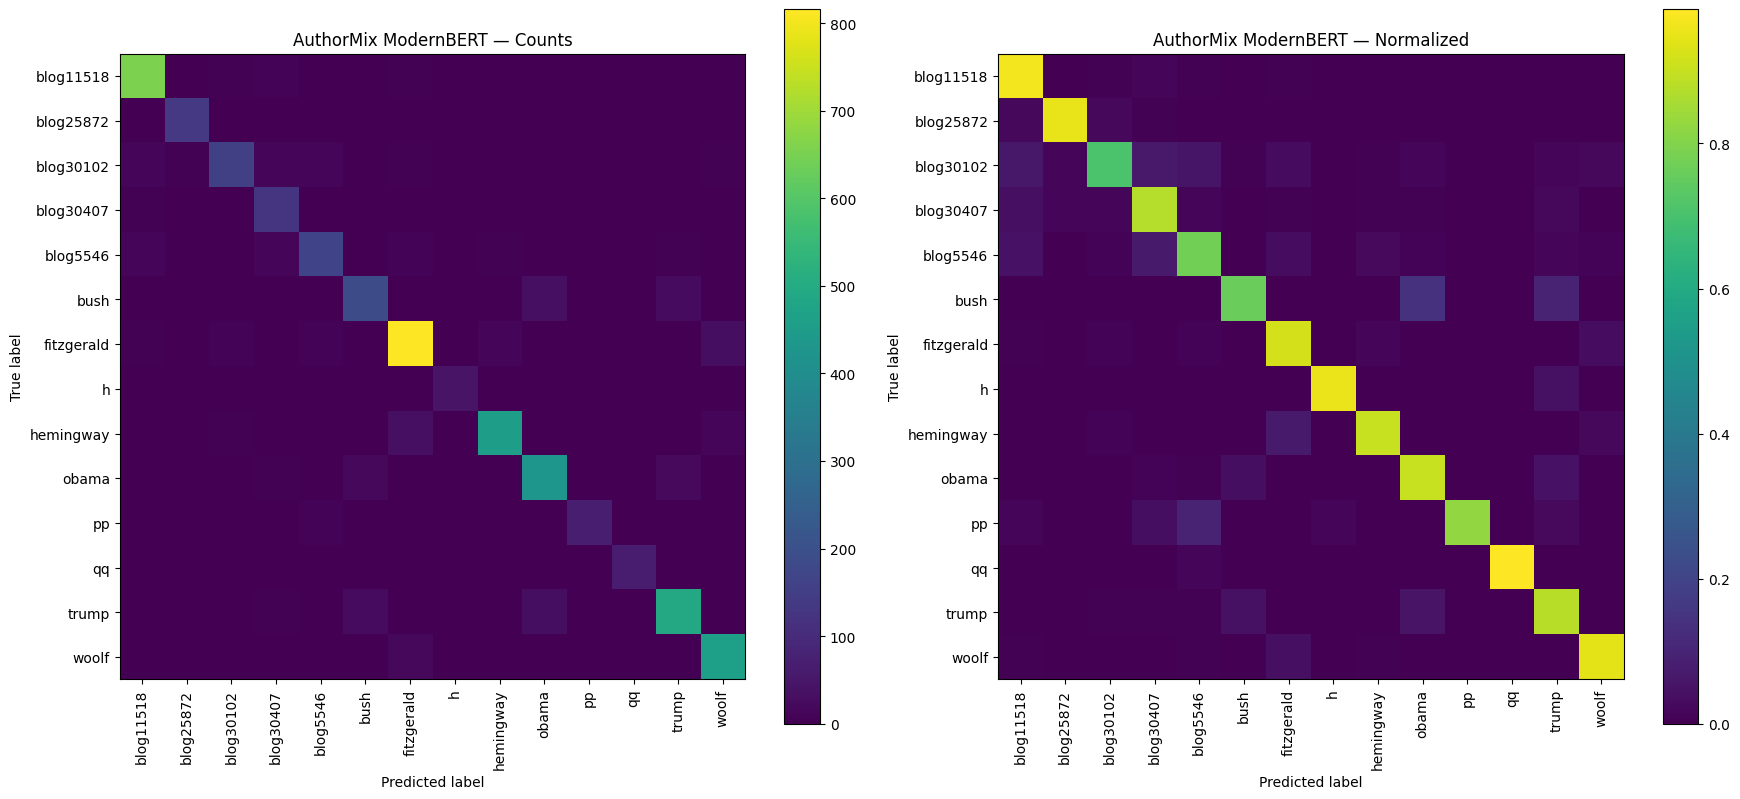

In [22]:
pred = best_am["trainer"].predict(amix_tok["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=-1)
names_am = list(le_am.classes_)
labels   = np.arange(len(names_am))

cm_am      = confusion_matrix(y_true, y_pred, labels=labels)
cm_am_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, mat, title in zip(
    axes,
    [cm_am, cm_am_norm],
    ["AuthorMix ModernBERT — Counts", "AuthorMix ModernBERT — Normalized"],
):
    ConfusionMatrixDisplay(mat, display_labels=names_am).plot(
        include_values=False, xticks_rotation=90, ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_modernbert_confusion_seed{best_am['seed']}.png", dpi=200)
plt.show()

,class,precision,recall,f1,support
2,blog30102,0.840659,0.705069,0.766917,217.0
3,blog30407,0.710227,0.874126,0.783699,143.0
4,blog5546,0.795122,0.776190,0.785542,210.0
5,bush,0.816239,0.760956,0.787629,251.0
9,obama,0.856000,0.901053,0.877949,475.0
12,trump,0.884685,0.879928,0.882300,558.0
10,pp,1.000000,0.823529,0.903226,85.0
6,fitzgerald,0.917885,0.922034,0.919955,885.0
8,hemingway,0.947808,0.900794,0.923703,504.0
13,woolf,0.905697,0.944672,0.924774,488.0


Saved per-class report to: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_per_class_report_seed11.csv


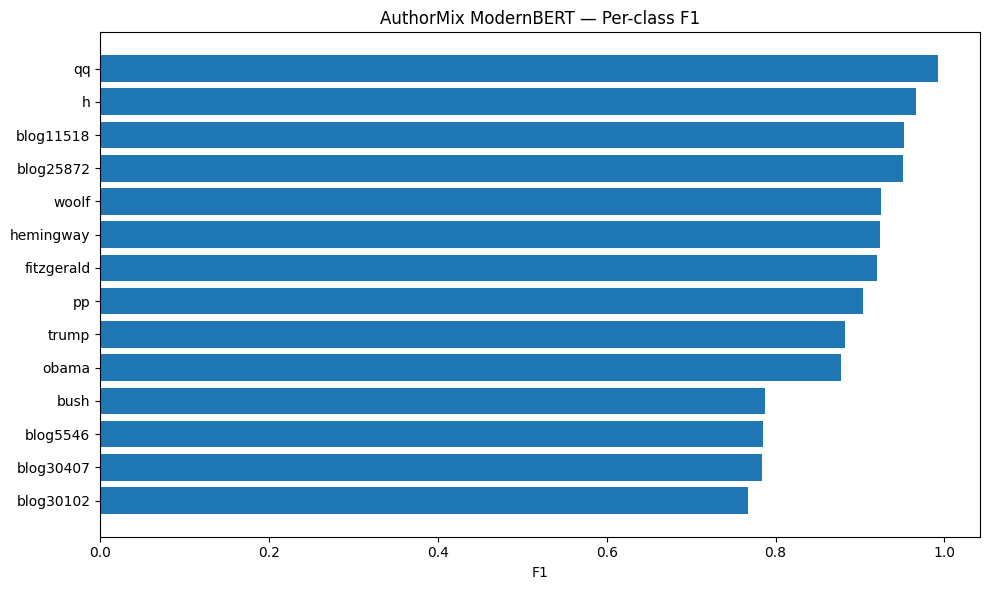

In [ ]:
report = classification_report(y_true, y_pred, target_names=names_am, output_dict=True, zero_division=0)
df_rep = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class", "f1-score": "f1"})
df_classes = df_rep[df_rep["class"].isin(names_am)].sort_values("f1", ascending=True)
display(df_classes[["class", "precision", "recall", "f1", "support"]])

out_csv = f"{RUNS_ROOT}/results/authormix_modernbert_per_class_report_seed{best_am['seed']}.csv"
df_classes.to_csv(out_csv, index=False)
print("Saved per-class report to:", out_csv)

plt.figure(figsize=(10, 6))
plt.barh(df_classes["class"], df_classes["f1"])
plt.title("AuthorMix ModernBERT — Per-class F1")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_modernbert_per_class_f1.png", dpi=200)
plt.show()

## Summary - ModernBERT vs. BERT baselines

The cell below compares ModernBERT results against the BERT baseline CSVs.

In [ ]:
summary_rows = []

for tag, bert_csv, mb_csv in [
    ("PAN25 multiclass",
     f"{RUNS_ROOT}/results/pan25_multiclass_seeds.csv",
     f"{RUNS_ROOT}/results/pan25_multiclass_modernbert_seeds.csv"),
    ("AuthorMix",
     f"{RUNS_ROOT}/results/authormix_seeds.csv",
     f"{RUNS_ROOT}/results/authormix_modernbert_seeds.csv"),
]:
    for model_name, path in [("BERT", bert_csv), ("ModernBERT", mb_csv)]:
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        col = "eval_balanced_accuracy" if "eval_balanced_accuracy" in df.columns else "eval_f1_macro"
        summary_rows.append({
            "dataset":  tag,
            "model":    model_name,
            "metric":   col,
            "mean":     round(df[col].mean(), 4),
            "std":      round(df[col].std(), 4),
            "best":     round(df[col].max(), 4),
        })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

out = f"{RUNS_ROOT}/results/modernbert_vs_bert_summary.csv"
df_summary.to_csv(out, index=False)
print("Saved comparison summary to:", out)

,dataset,model,metric,mean,std,best
0,PAN25 multiclass,BERT,eval_balanced_accuracy,0.6152,0.0088,0.6226
1,PAN25 multiclass,ModernBERT,eval_balanced_accuracy,0.7967,0.0065,0.8024
2,AuthorMix,BERT,eval_balanced_accuracy,0.8572,0.0052,0.8617
3,AuthorMix,ModernBERT,eval_balanced_accuracy,0.8784,0.0041,0.8818


Saved comparison summary to: /content/drive/MyDrive/ap-thesis/runs/results/modernbert_vs_bert_summary.csv
